In [1]:
from langgraph.graph import StateGraph, START, END
from spm_agent.nodes.readfile_node import readfile_node
from spm_agent.nodes.channel_recommendation_node import channel_recommendation_node
from spm_agent.nodes.agentic_segmentation_node import agentic_segmentation_node

from spm_agent.states.image_analysis_state import ImageAnalysisState

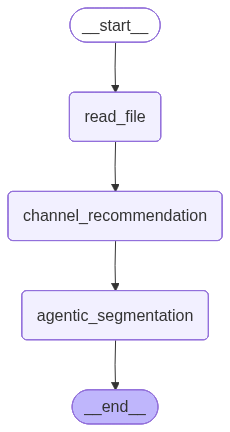

In [2]:
builder = StateGraph(ImageAnalysisState)
builder.add_node("read_file", readfile_node)
builder.add_node("channel_recommendation", channel_recommendation_node)
builder.add_node("agentic_segmentation", agentic_segmentation_node)

builder.add_edge(START, "read_file")
builder.add_edge("read_file", "channel_recommendation")
builder.add_edge("channel_recommendation", "agentic_segmentation")
builder.add_edge("agentic_segmentation", END)

im_graph = builder.compile()
im_graph

In [3]:
from spm_agent.config import SCIFIREADERS_MCP_COMMAND
print(SCIFIREADERS_MCP_COMMAND)

/Users/borisslautin/Documents/GitHub/SPM_agent_simple/.venv/bin/scifireaders_mcp


In [4]:
result = await im_graph.ainvoke(
    {
        "file_path": r"/Users/borisslautin/Documents/!!UTK/agentic_SPM/260618/PLZT_agent/PLZT_0000.ibw",
    }
)

In [5]:
result

{'file_path': '/Users/borisslautin/Documents/!!UTK/agentic_SPM/260618/PLZT_agent/PLZT_0000.ibw',
 'file_channels': {'Channel_000': {'title': 'HeightRetrace',
   'units': 'm',
   'data_type': 'IMAGE',
   'shape': [256, 256],
   'stats': {'min': -5.82986103836447e-09,
    'max': 3.6088152910451754e-08,
    'mean': -2.179246366695864e-17,
    'std': 1.4608724275743564e-09,
    'p01': -2.9589962480258692e-09,
    'p99': 3.2140533789970508e-09},
   'preview_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/HeightRetrace.png',
   'array_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/HeightRetrace.npy'},
  'Channel_001': {'title': 'Amplitude1Retrace',
   'units': 'm',
   'data_type': 'IMAGE',
   'shape': [256, 256],
   'stats': {'min': 1.0444874999626652e-11,
    'max': 1.2763735901533124e-10,
    'mean': 3.770159796518954e-11,
    'std': 1.9521250217870767e-11,
    'p01': 1.4624989500694462e-11,
    'p99': 8